# Tekken 8 Season 2 Review Analysis

Steam review analysis using TF-IDF, manual keyword validation, and multi-label issue tagging.

**Key result:** after Season 2 / v2.00.01, the largest aggregate issue-share increases were Defense_Movement (+9.82 pp), Character_Homogenization (+8.37 pp), and Dev_Direction_Trust (+6.13 pp). These are observed associations, not causal patch effects.

## 1. Analysis question

Which gameplay issues became more prominent in reviews collected after Tekken 8 Season 2 / v2.00.01, and how did patterns differ between Recommended and Not Recommended reviews?

## 2. Setup

This portfolio notebook uses repository-relative paths and the published aggregate outputs. Raw Steam reviews are intentionally not distributed in this repository.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
ROOT = next(path for path in [cwd, *cwd.parents] if (path / 'README.md').exists() and (path / 'data').is_dir())
DATA = ROOT / 'data' / 'processed'
FIGURES = ROOT / 'figures'

final_summary = pd.read_csv(DATA / 'tekken8_final_summary.csv')
pre_post = pd.read_csv(DATA / 'tekken8_issue_pre_post.csv')
by_recommendation = pd.read_csv(DATA / 'tekken8_issue_by_recommendation.csv')
validation = pd.read_csv(DATA / 'keyword_validation_summary.csv')
dictionary = pd.read_csv(DATA / 'tekken8_issue_tag_dictionary_v02.csv')
coverage = pd.read_csv(DATA / 'tagging_summary.csv')
qa_examples = pd.read_csv(DATA / 'tagging_qa_examples.csv')
quality_checks = pd.read_csv(DATA / 'analysis_quality_checks.csv')

## 3. Data range and recommendation rate

In [2]:
overview_metrics = final_summary[final_summary['metric'].isin([
    'clean_review_count', 'PRE_review_count', 'POST_review_count',
    'PRE_recommended_rate', 'POST_recommended_rate', 'recommended_rate_change'
])].copy()
display(overview_metrics)

,metric,value,unit,note
2,clean_review_count,4234.000000,reviews,PRE + POST
3,PRE_review_count,193.000000,reviews,clean window
4,POST_review_count,4041.000000,reviews,clean window
5,PRE_recommended_rate,0.611399,share,Recommended / PRE
6,POST_recommended_rate,0.067805,share,Recommended / POST
7,recommended_rate_change,-54.359396,percentage_points,POST minus PRE


The clean comparison contains 4,234 reviews: 193 PRE and 4,041 POST. The Recommended rate was 61.1% PRE and 6.8% POST. The difference is descriptive and should not be read as a causal patch effect.

## 4. Frequency / TF-IDF candidate process

Frequency and TF-IDF were used to surface candidate terms. Candidates were then classified and manually validated in context before they could inform the issue dictionary. Raw frequency alone did not create an issue tag.

## 5. Manual keyword validation

In [3]:
display(validation[['keyword', 'validation_type', 'checked', 'TP', 'FP', 'UNSURE', 'classification', 'proposed_tag']])

,keyword,validation_type,checked,TP,FP,UNSURE,classification,proposed_tag
0,devs,core_45,5,5,0,0,Conditional,Dev_Direction_Trust
1,heat,core_45,5,5,0,0,Issue,Heat_System
2,character,core_45,5,5,0,0,Conditional,Character_Homogenization
3,characters,core_45,5,5,0,0,Conditional,Character_Homogenization
4,moves,core_45,5,5,0,0,Conditional,Moveset_Balance_Issue
5,changes,core_45,5,5,0,0,Context,NaN
6,patch,core_45,5,5,0,0,Context,NaN
7,season,core_45,5,5,0,0,Context,NaN
8,fighting,core_45,5,5,0,0,Context,NaN
9,defense,supplemental_5,5,5,0,0,Issue,Defense_Movement


Core validation contains 9 keywords × 5 reviews (45 contexts). Defense is a separate 5-review supplemental set. TP/FP evaluates whether a keyword is used in the intended topic sense; it is not a sentiment label.

## 6. Issue Tag Dictionary v0.2

In [4]:
display(dictionary[['tag_id', 'tag_name', 'description', 'conditional_keywords', 'negative_rules', 'validation_basis']])

,tag_id,tag_name,description,conditional_keywords,negative_rules,validation_basis
0,T01,Offensive_Pressure,"과도한 공격 우위, 압박, 강제 50/50 및 plus-frame 중심 gamepl...",aggression|aggressive|offense|offensive|pressu...,일반 pressure/offense 단독은 제외하고 강제성·과도함·50/50·방어 ...,Core 및 defense manual notes에서 공격 우위·plus frame...
1,T02,Defense_Movement,"방어 선택지, blocking, movement, sidestep, backdash...",movement|neutral|blocking + nerf/lack/punish/i...,movement/neutral/blocking 단독은 제외; 추천 리뷰의 개선·칭찬...,Defense supplemental 5/5 TP; POST 비추천 exact de...
2,T03,Character_Homogenization,캐릭터 아키타입·장단점·정체성이 비슷해지거나 획일화됐다는 언급,character|characters|roster + same/similar/ide...,character(s) 단독 및 구매·해금·단순 캐릭터명 언급은 제외,"character 5/5 TP, characters 5/5 TP; 단독어의 다의성 ..."
3,T04,Heat_System,"Tekken 8 Heat 시스템, mechanic, activation, engag...",NaN,명백한 비게임 관용구만 제외; 추천 리뷰 태깅은 불만으로 자동 해석하지 않음,heat 5/5 TP 및 고유 시스템 명칭으로 Issue 분류
4,T05,Moveset_Balance_Issue,"기술 구성, frame data, tracking, off-axis, damage,...",move|moves + removed/nerfed/buffed/broken/bug/...,move(s) 단독과 단순 기술 설명은 제외하고 속성·밸런스·버그·강제 상황 문맥을 요구,moves 5/5 TP였지만 일반어이므로 Conditional 분류
5,T06,Dev_Direction_Trust,"개발 방향, 커뮤니티 피드백, 신뢰, 소통 및 개발진 판단에 대한 언급",dev|devs|developer|developers|Bandai Namco|Har...,dev(s)/developer(s) 단독은 제외; 추천 리뷰에서 긍정적 소통 언급이...,devs 5/5 TP였지만 긍정·중립 사용 가능성 때문에 Conditional


The rules use lowercase normalization, regex word boundaries, phrase priority, conditional cues, and exclusions. Context keywords cannot tag a review alone, and one review may receive multiple tags.

## 7. Tagging coverage

In [5]:
display(coverage)

,coverage_group,n,tag_id,tag_name,tag_count,tag_share
0,Overall,4234,T01,Offensive_Pressure,738,0.174303
1,Overall,4234,T02,Defense_Movement,726,0.171469
2,Overall,4234,T03,Character_Homogenization,426,0.100614
3,Overall,4234,T04,Heat_System,274,0.064714
4,Overall,4234,T05,Moveset_Balance_Issue,327,0.077232
5,Overall,4234,T06,Dev_Direction_Trust,511,0.120690
6,PRE,193,T01,Offensive_Pressure,28,0.145078
7,PRE,193,T02,Defense_Movement,15,0.077720
8,PRE,193,T03,Character_Homogenization,4,0.020725
9,PRE,193,T04,Heat_System,17,0.088083


One or more issue tags were assigned to 1,403 reviews (33.14%). Coverage was 21.76% PRE, 33.68% POST, 11.48% Recommended, and 35.35% Not Recommended.

## 8. PRE / POST issue shares

In [6]:
display(pre_post)

,tag_id,tag_name,PRE_n,PRE_count,PRE_share,POST_n,POST_count,POST_share,percentage_point_change
0,T01,Offensive_Pressure,193,28,0.145078,4041,710,0.175699,3.062136
1,T02,Defense_Movement,193,15,0.077720,4041,711,0.175947,9.822634
2,T03,Character_Homogenization,193,4,0.020725,4041,422,0.104430,8.370421
3,T04,Heat_System,193,17,0.088083,4041,257,0.063598,-2.448478
4,T05,Moveset_Balance_Issue,193,12,0.062176,4041,315,0.077951,1.577484
5,T06,Dev_Direction_Trust,193,12,0.062176,4041,499,0.123484,6.130812


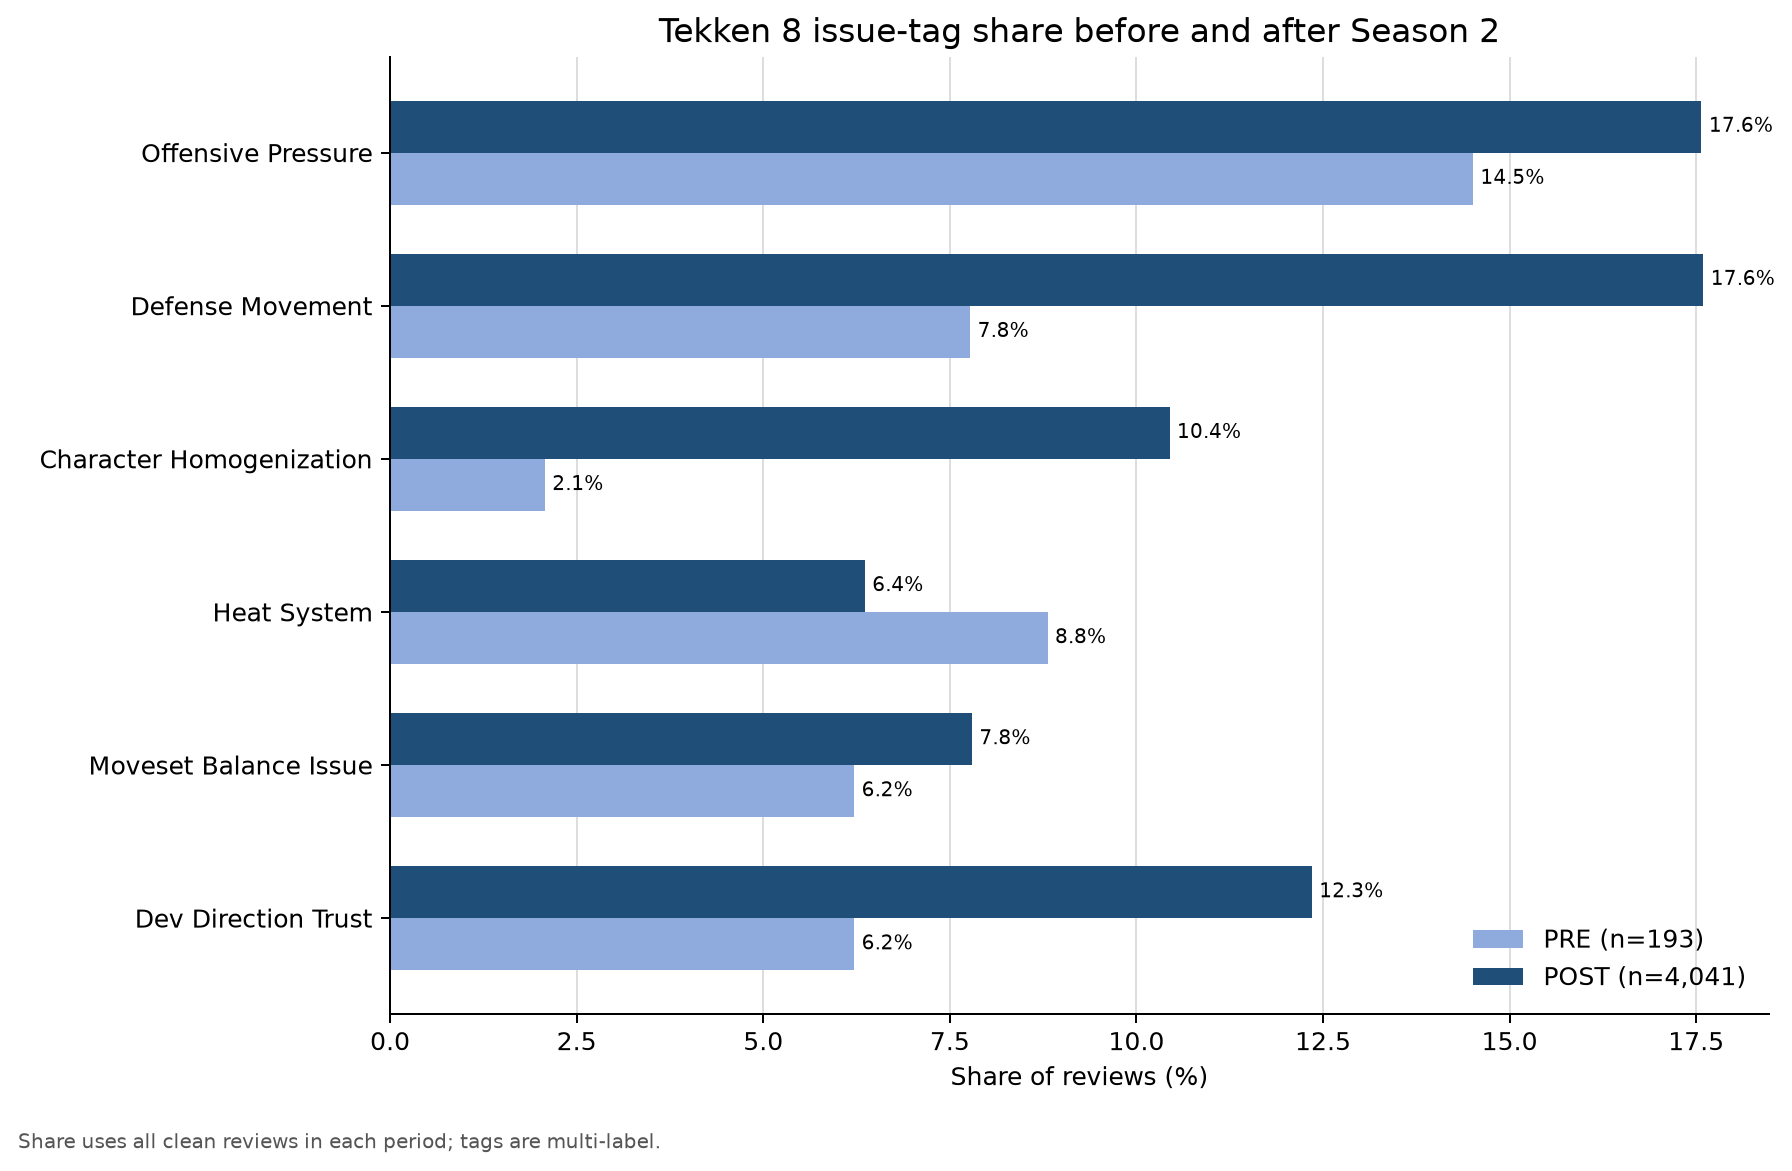

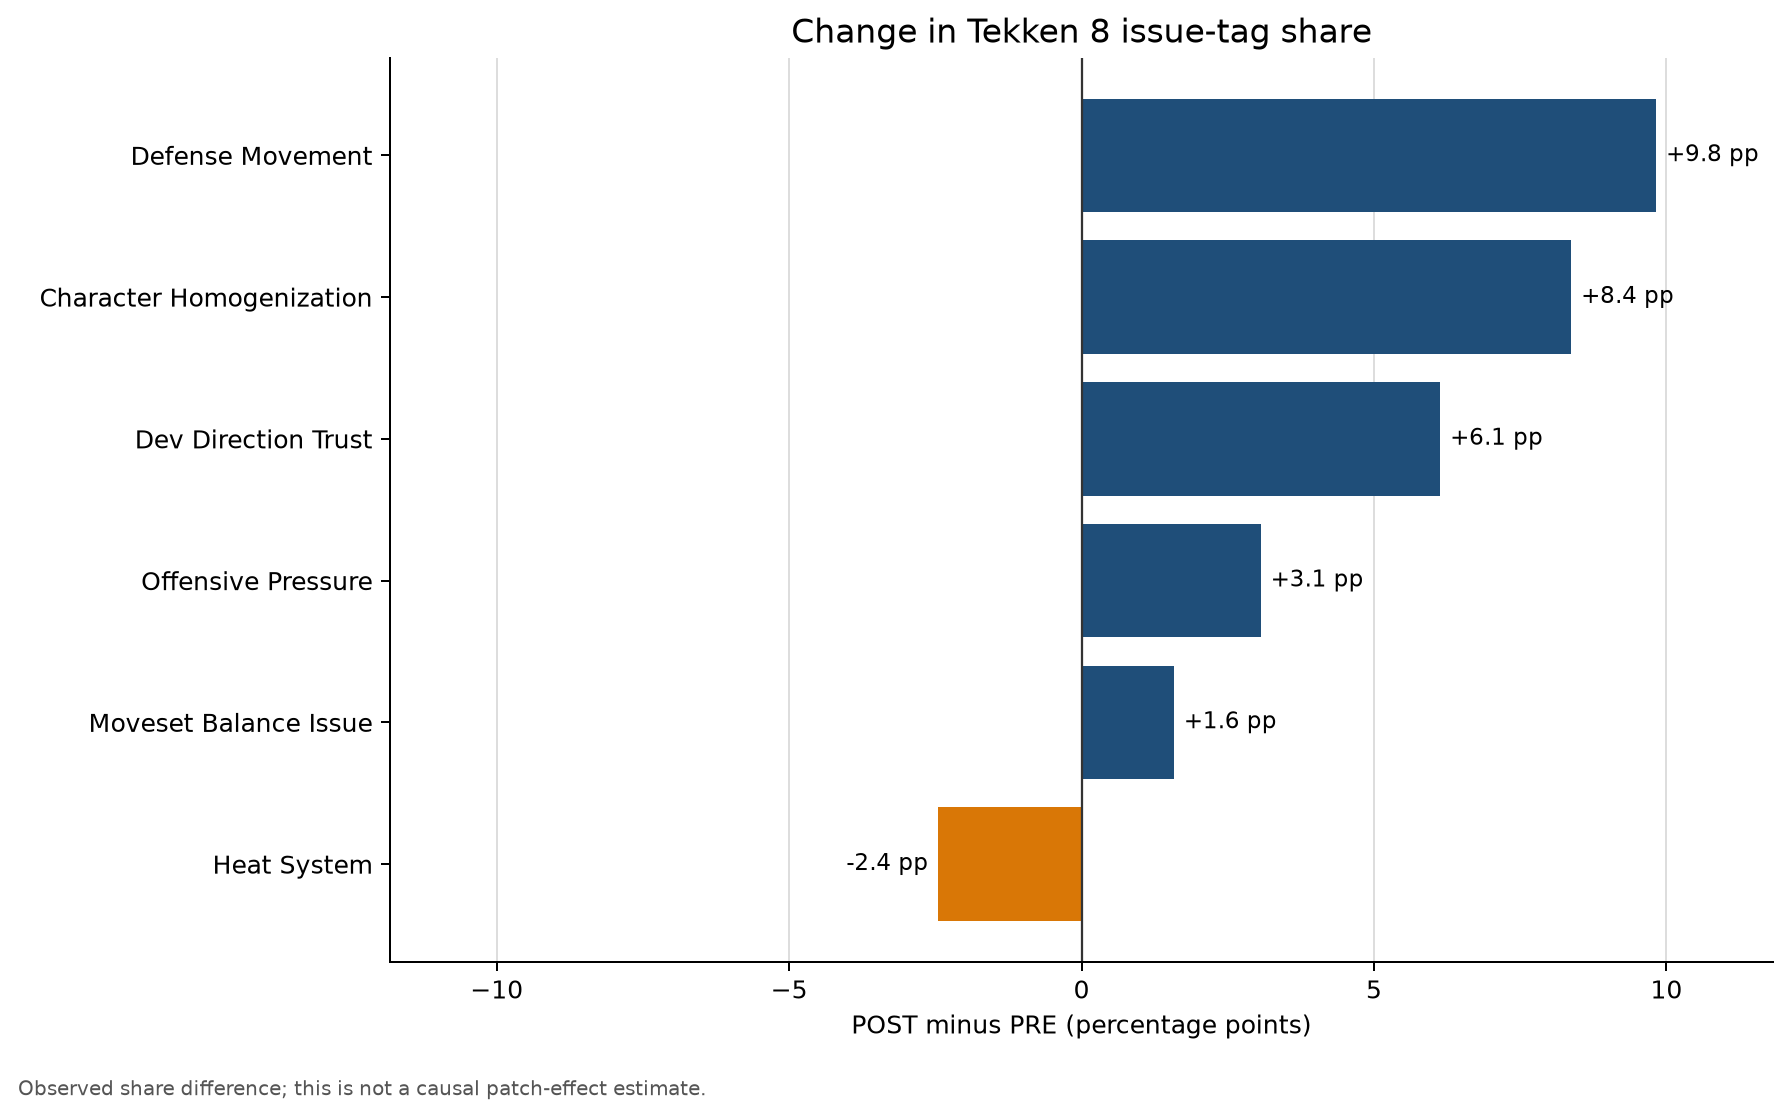

In [7]:
display(Image(filename=str(FIGURES / 'tekken8_issue_share_pre_post.png')))
display(Image(filename=str(FIGURES / 'tekken8_issue_percentage_point_change.png')))

Defense_Movement rose 7.77% → 17.59% (+9.82 pp), Character_Homogenization 2.07% → 10.44% (+8.37 pp), and Dev_Direction_Trust 6.22% → 12.35% (+6.13 pp).

## 9. Recommended / Not Recommended comparison

In [8]:
display(by_recommendation)

,analysis_group,period,recommendation_group,n,tag_id,tag_name,tag_count,tag_share
0,PRE_Recommended,PRE,Recommended,118,T01,Offensive_Pressure,4,0.033898
1,PRE_Recommended,PRE,Recommended,118,T02,Defense_Movement,1,0.008475
2,PRE_Recommended,PRE,Recommended,118,T03,Character_Homogenization,2,0.016949
3,PRE_Recommended,PRE,Recommended,118,T04,Heat_System,4,0.033898
4,PRE_Recommended,PRE,Recommended,118,T05,Moveset_Balance_Issue,4,0.033898
5,PRE_Recommended,PRE,Recommended,118,T06,Dev_Direction_Trust,1,0.008475
6,PRE_Not_Recommended,PRE,Not Recommended,75,T01,Offensive_Pressure,24,0.320000
7,PRE_Not_Recommended,PRE,Not Recommended,75,T02,Defense_Movement,14,0.186667
8,PRE_Not_Recommended,PRE,Not Recommended,75,T03,Character_Homogenization,2,0.026667
9,PRE_Not_Recommended,PRE,Not Recommended,75,T04,Heat_System,13,0.173333


Defense_Movement was nearly unchanged within Not Recommended reviews (18.67% PRE vs 18.50% POST), showing that its aggregate increase was partly compositional. Character_Homogenization increased within the same group from 2.67% to 10.88%, making it a more distinct post-update signal.

## 10. Representative review context

In [9]:
qa_preview = qa_examples.copy()
qa_preview['review_excerpt'] = qa_preview['review_text'].str.replace(r'\s+', ' ', regex=True).str.slice(0, 360)
display(qa_preview[['tag_name', 'period', 'recommendation_group', 'recommendationid', 'matched_terms', 'review_excerpt']])

,tag_name,period,recommendation_group,recommendationid,matched_terms,review_excerpt
0,Offensive_Pressure,PRE,Recommended,191488513,50/50,"Unprecedented gameplay, other fighting games c..."
1,Offensive_Pressure,PRE,Not Recommended,191027261,50/50s|aggressive|difficult|worst|punish|issue...,To preface: I am a complete newcomer to fighti...
2,Offensive_Pressure,POST,Recommended,192481852,plus frames|50/50|offensive|mix-up|lacks|diffi...,Tekken 8 is a flawed fighting game that leans ...
3,Offensive_Pressure,POST,Not Recommended,191933786,too aggressive|aggressive|rushdown|ignoring|sa...,I remember when my friend first got me into Te...
4,Defense_Movement,PRE,Recommended,190657738,defense|side-stepping|blocking|guess|unbalance...,im recommending this game but know this: its a...
5,Defense_Movement,PRE,Not Recommended,191027261,sidestep|movement|difficult|worst|punish|issue...,To preface: I am a complete newcomer to fighti...
6,Defense_Movement,POST,Recommended,192481852,defensive|neutral|lacks|difficult|guess|issues...,Tekken 8 is a flawed fighting game that leans ...
7,Defense_Movement,POST,Not Recommended,191933786,defense|backdash|sidestep|movement|ignoring|sa...,I remember when my friend first got me into Te...
8,Character_Homogenization,PRE,Recommended,190657738,character|characters|roster|everyone|same,im recommending this game but know this: its a...
9,Character_Homogenization,PRE,Not Recommended,191153558,characters|weaknesses,"As a new player, I really liked the game. Desp..."


Recommended reviews containing an issue tag were not automatically interpreted as complaints. The recommendation group and original context were retained for interpretation.

## 11. Quality checks

In [10]:
display(quality_checks)
assert quality_checks['passed'].all()

,check,passed,detail
0,clean_review_count,True,4234
1,recommendationid_unique,True,0
2,period_labels_valid,True,"[""POST"", ""PRE""]"
3,recommendation_labels_valid,True,"[""Not Recommended"", ""Recommended""]"
4,tag_values_binary,True,all tag columns
5,issue_tag_count_reconciles,True,row-wise tag sum
6,pre_post_shares_in_range,True,0 <= share <= 1
7,recommendation_shares_in_range,True,0 <= share <= 1
8,percentage_point_change_reconciles,True,100 * (POST_share - PRE_share)
9,input_hashes_unchanged,True,all analysis inputs


## 12. Limitations and conclusion

The PRE/POST samples are imbalanced, Steam reviews are self-selected, manual validation is small, and regex tagging cannot resolve every context. Multi-label shares overlap. The evidence is observational.

The strongest result is not simply that defense mentions increased in aggregate, but that composition explains much of that increase, while character homogenization also rose within Not Recommended reviews.